# Live Demo: Guided Backpropagation, Grad-CAM and Guided Grad-CAM

This notebook demonstrates the key visual explanation methods from the Grad-CAM paper on a simple image containing **two different animals**: a cat and a dog.

The goal is to show the main idea clearly:

- **Guided Backpropagation** produces sharp details, but is not very class-discriminative.
- **Grad-CAM** produces a coarse heatmap that changes with the target class.
- **Guided Grad-CAM** combines both: class-discriminative localization and fine visual details.


In [10]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt
import torch

from torchvision.models import resnet50, ResNet50_Weights
from pytorch_grad_cam import GradCAM, GuidedBackpropReLUModel
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image, deprocess_image

print("Imports successfully loaded.")

Imports successfully loaded.


## Step 1: Load the model and the image

We use a pre-trained **ResNet50** model and a simple cat-and-dog image that is **not the example image from the paper**.

For Grad-CAM, we use the last convolutional block of ResNet50. This layer is a good choice because it still preserves spatial information while already representing high-level object features.


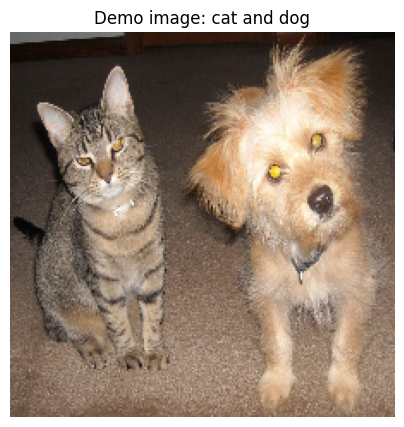

In [11]:
# Load the pre-trained ResNet50 model
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Grad-CAM is usually applied to the last convolutional layer.
target_layers = [model.layer4[-1]]

# Simple image with one cat and one dog.
# Source: PublicDomainPictures.net, CC0 Public Domain.
url = "https://www.publicdomainpictures.net/pictures/10000/velka/1377-1244933977c4kR.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
image_bytes = bytearray(requests.get(url, headers=headers, timeout=20).content)
image_np = np.array(image_bytes, dtype=np.uint8)

# Decode image and convert BGR -> RGB
rgb_img = cv2.imdecode(image_np, cv2.IMREAD_COLOR)
if rgb_img is None:
    raise ValueError("Image could not be loaded. Please check the image URL or your internet connection.")

rgb_img = rgb_img[:, :, ::-1]

# Resize to keep the demo fast and stable.
rgb_img = cv2.resize(rgb_img, (224, 224))
rgb_img = np.float32(rgb_img) / 255.0

# Prepare image for ResNet50.
input_tensor = preprocess_image(
    rgb_img,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
).to(device)

plt.figure(figsize=(5, 5))
plt.imshow(rgb_img)
plt.axis("off")
plt.title("Demo image: cat and dog")
plt.show()

## Step 2: Choose the target classes

To demonstrate class discrimination, we ask the same model two different questions about the same image:

- Where is the evidence for the **cat** class?
- Where is the evidence for the **dog** class?

We manually select one ImageNet cat class and one ImageNet dog class that match the image reasonably well.


In [12]:
categories = weights.meta["categories"]

cat_class_name = "tabby"
dog_class_name = "Norfolk terrier"

cat_class_id = categories.index(cat_class_name)
dog_class_id = categories.index(dog_class_name)

print(f"Cat target: {cat_class_name} (ImageNet ID: {cat_class_id})")
print(f"Dog target: {dog_class_name} (ImageNet ID: {dog_class_id})")

Cat target: tabby (ImageNet ID: 281)
Dog target: Norfolk terrier (ImageNet ID: 185)


## Step 3: Guided Backpropagation

Guided Backpropagation visualizes gradients with respect to the input image.

It produces sharp, high-resolution edge and texture information. However, it is often **not clearly class-discriminative**: the visualizations for the cat and dog targets can look very similar because both are based on low-level image details.


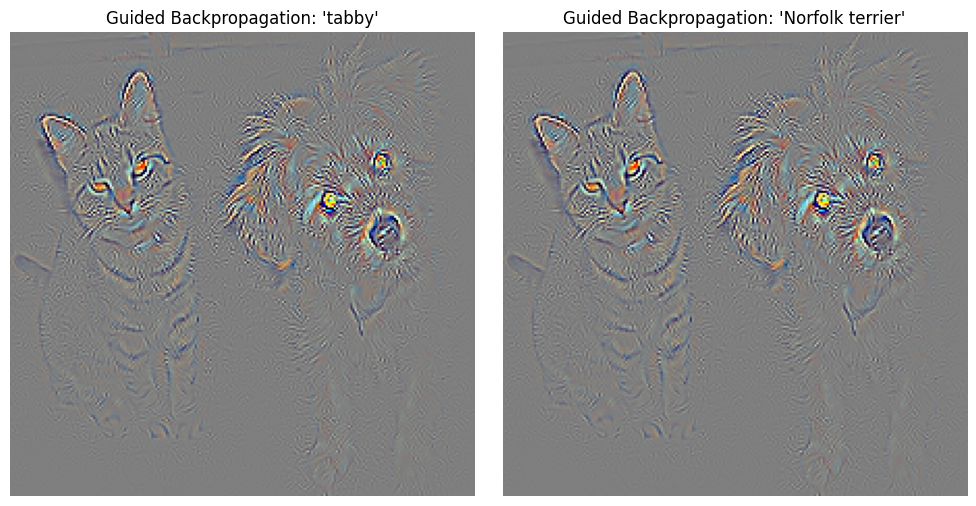

In [13]:
# Guided Backpropagation modifies the backward pass through ReLU layers.
gb_model = GuidedBackpropReLUModel(model=model, device=device)

# Compute Guided Backpropagation for both target classes.
gb_cat = gb_model(input_tensor, target_category=cat_class_id)
gb_dog = gb_model(input_tensor, target_category=dog_class_id)

gb_cat_visual = deprocess_image(gb_cat)
gb_dog_visual = deprocess_image(gb_dog)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(gb_cat_visual)
axs[0].set_title(f"Guided Backpropagation: '{cat_class_name}'")
axs[0].axis("off")

axs[1].imshow(gb_dog_visual)
axs[1].set_title(f"Guided Backpropagation: '{dog_class_name}'")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Step 4: Grad-CAM

Grad-CAM produces a coarse heatmap for a specific target class.

This is the key class-discriminative part: when we change the target from cat to dog, the highlighted region should move to the corresponding animal.


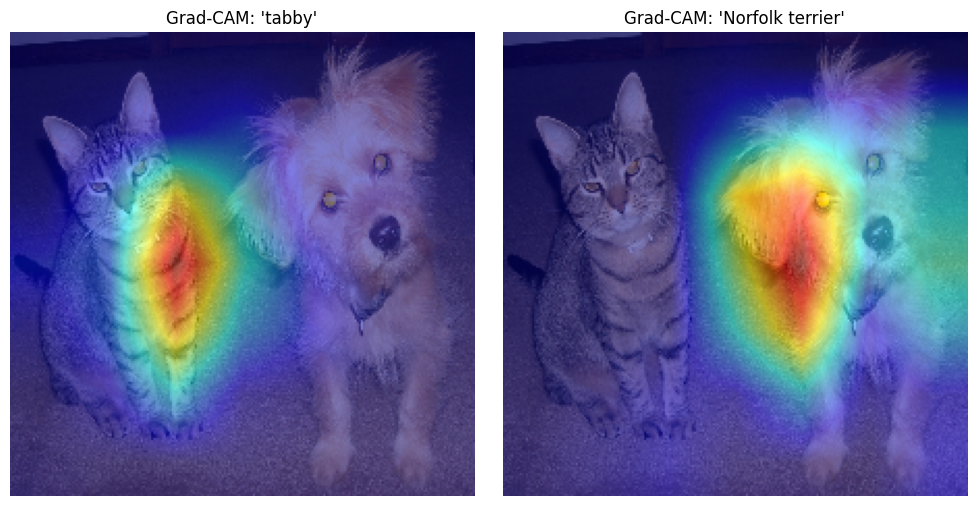

In [14]:
cam = GradCAM(model=model, target_layers=target_layers)

# Grad-CAM for the cat target
cat_targets = [ClassifierOutputTarget(cat_class_id)]
grayscale_cam_cat = cam(input_tensor=input_tensor, targets=cat_targets)[0, :]
visualization_cat = show_cam_on_image(rgb_img, grayscale_cam_cat, use_rgb=True)

# Grad-CAM for the dog target
dog_targets = [ClassifierOutputTarget(dog_class_id)]
grayscale_cam_dog = cam(input_tensor=input_tensor, targets=dog_targets)[0, :]
visualization_dog = show_cam_on_image(rgb_img, grayscale_cam_dog, use_rgb=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(visualization_cat)
axs[0].set_title(f"Grad-CAM: '{cat_class_name}'")
axs[0].axis("off")

axs[1].imshow(visualization_dog)
axs[1].set_title(f"Grad-CAM: '{dog_class_name}'")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Step 5: Guided Grad-CAM

Guided Grad-CAM combines the strengths of both methods:

- Grad-CAM provides the class-specific region.
- Guided Backpropagation provides fine-grained visual detail.

The result is a high-resolution visualization that is still guided by the selected target class.


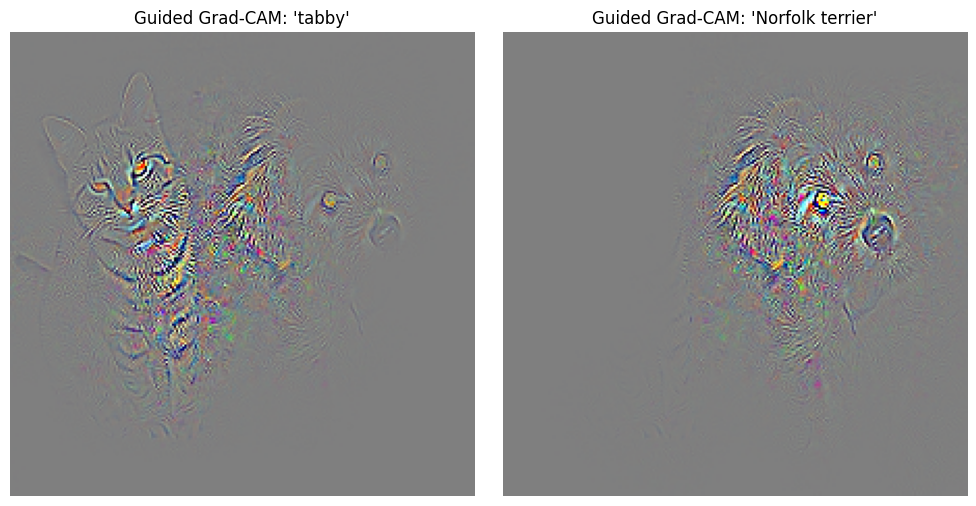

In [15]:
# Combine Grad-CAM with Guided Backpropagation.
# The Grad-CAM heatmap is used as a mask for the high-resolution Guided Backpropagation signal.
cam_mask_cat = cv2.merge([grayscale_cam_cat, grayscale_cam_cat, grayscale_cam_cat])
cam_mask_dog = cv2.merge([grayscale_cam_dog, grayscale_cam_dog, grayscale_cam_dog])

guided_gradcam_cat = deprocess_image(cam_mask_cat * gb_cat)
guided_gradcam_dog = deprocess_image(cam_mask_dog * gb_dog)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(guided_gradcam_cat)
axs[0].set_title(f"Guided Grad-CAM: '{cat_class_name}'")
axs[0].axis("off")

axs[1].imshow(guided_gradcam_dog)
axs[1].set_title(f"Guided Grad-CAM: '{dog_class_name}'")
axs[1].axis("off")

plt.tight_layout()
plt.show()